<a href="https://colab.research.google.com/github/Prachisoni07/ml/blob/main/Fast_SCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision
!pip install segmentation-models-pytorch
!pip install opencv-python


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
import torch
import segmentation_models_pytorch as smp
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image


In [22]:

model = smp.FastSCNN(
    encoder_weights="imagenet",
    in_channels=3,
    classes=21


model.eval()


AttributeError: module 'segmentation_models_pytorch' has no attribute 'FastSCNN'

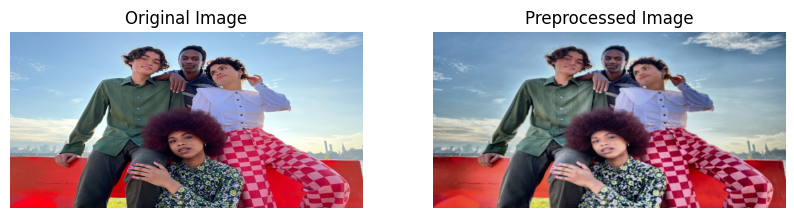

In [19]:

image_path = "/content/ayushu152.00.jpeg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = cv2.resize(image, (1024, 512))

image_blur = cv2.GaussianBlur(image, (5, 5), 0)


lab = cv2.cvtColor(image_blur, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l = clahe.apply(l)
lab = cv2.merge((l, a, b))
image_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

edges = cv2.Canny(image_clahe, 100, 200)


edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
image_preprocessed = cv2.addWeighted(image_clahe, 0.9, edges_colored, 0.1, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_preprocessed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()


In [20]:

image_pil = Image.fromarray(image_preprocessed)

transform = transforms.Compose([
    transforms.ToTensor(),
])

image_tensor = transform(image_pil).unsqueeze(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=21,
)


model.eval()

model.to(device)


with torch.no_grad():
    output = model(image_tensor)

output = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

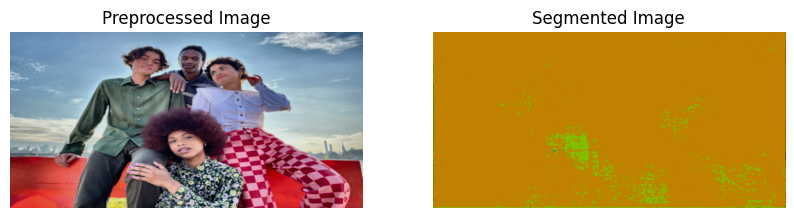

In [21]:

def apply_colormap(mask):
    colormap = np.array([
        [0, 0, 0],  # Background
        [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0],
        [192, 0, 0], [64, 128, 0], [192, 128, 0], [64, 0, 128],
        [192, 0, 128], [64, 128, 128], [192, 128, 128], [0, 64, 0],
        [128, 64, 0], [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ])

    colored_mask = colormap[mask]
    return colored_mask


segmentation_result = apply_colormap(output)


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_preprocessed)
ax[0].set_title("Preprocessed Image")
ax[0].axis("off")

ax[1].imshow(segmentation_result)
ax[1].set_title("Segmented Image")
ax[1].axis("off")

plt.show()



In [1]:
!pip install torch torchvision opencv-python matplotlib pycocotools tqdm
!pip install fiftyone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.coco import COCO
from PIL import Image
import fiftyone.zoo as foz


In [8]:
import fiftyone as fo
import fiftyone.zoo as foz

# Load the COCO 2017 dataset with segmentation annotations
dataset = foz.load_zoo_dataset("coco-2017", split="train", dataset_type="coco-segmentation")

# Get dataset directory and annotation file
coco_images_dir = dataset.dataset_dir  # Root dataset directory
coco_ann_file = dataset.info.get("annotation_path", "Annotation file not found")  # Get annotation path

print("COCO Images Directory:", coco_images_dir)
print("COCO Annotation File:", coco_ann_file)





INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


Images already downloaded


INFO:fiftyone.utils.coco:Images already downloaded


...

INFO:fiftyone.zoo.datasets:Existing download of split 'train' is sufficient


Ignoring unsupported parameter 'dataset_type' for importer type <class 'fiftyone.utils.coco.COCODetectionDatasetImporter'>


Loading existing dataset 'coco-2017-train'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'coco-2017-train'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


AttributeError: 'Dataset' object has no attribute 'dataset_dir'

In [13]:
!pip install torch torchvision opencv-python matplotlib pycocotools tqdm
!pip install fiftyone  # For automatic COCO dataset handling


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.coco import COCO
from PIL import Image
import fiftyone.zoo as foz  # Auto-download dataset


In [22]:
!mkdir -p coco_dataset && cd coco_dataset
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip train2017.zip -d images
!unzip annotations_trainval2017.zip -d annotations


Streaming output truncated to the last 5000 lines.
 extracting: images/train2017/000000381931.jpg  
 extracting: images/train2017/000000569592.jpg  
 extracting: images/train2017/000000229396.jpg  
 extracting: images/train2017/000000488990.jpg  
 extracting: images/train2017/000000348684.jpg  
 extracting: images/train2017/000000234031.jpg  
 extracting: images/train2017/000000563584.jpg  
 extracting: images/train2017/000000276069.jpg  
 extracting: images/train2017/000000401194.jpg  
 extracting: images/train2017/000000502089.jpg  
 extracting: images/train2017/000000192183.jpg  
 extracting: images/train2017/000000425127.jpg  
 extracting: images/train2017/000000126766.jpg  
 extracting: images/train2017/000000324161.jpg  
 extracting: images/train2017/000000452746.jpg  
 extracting: images/train2017/000000423782.jpg  
 extracting: images/train2017/000000546343.jpg  
 extracting: images/train2017/000000249290.jpg  
 extracting: images/train2017/000000025529.jpg  
 extracting: image

In [18]:
coco_images_dir = "coco_dataset/images/train2017"
coco_ann_file = "coco_dataset/annotations/instances_train2017.json"


In [19]:
class _ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(_ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class _DSConv(nn.Module):
    def __init__(self, dw_channels, out_channels, stride=1):
        super(_DSConv, self).__init__()
        self.dw_conv = nn.Conv2d(dw_channels, dw_channels, 3, stride, 1, groups=dw_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(dw_channels)
        self.pointwise_conv = nn.Conv2d(dw_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.dw_conv(x)))
        x = self.relu(self.bn2(self.pointwise_conv(x)))
        return x

class FastSCNN(nn.Module):
    def __init__(self, num_classes=171):  # COCO has 171 segmentation classes
        super(FastSCNN, self).__init__()
        self.downsample = nn.Sequential(
            _ConvBNReLU(3, 32, 3, 2, 1),
            _DSConv(32, 48, 2),
            _DSConv(48, 64, 2)
        )
        self.global_feature_extractor = nn.Sequential(
            _DSConv(64, 128, 2),
            _DSConv(128, 256, 1),
            _DSConv(256, 256, 1),
            nn.AdaptiveAvgPool2d(1),
            _ConvBNReLU(256, 128, 1)
        )
        self.feature_fusion = nn.Sequential(
            _ConvBNReLU(192, 128, 1),
            nn.Conv2d(128, num_classes, 1)
        )
        self.classifier = nn.Sequential(
            _DSConv(num_classes, num_classes),
            nn.ConvTranspose2d(num_classes, num_classes, 2, 2),
            nn.ConvTranspose2d(num_classes, num_classes, 2, 2)
        )

    def forward(self, x):
        size = x.size()[2:]
        high_res_features = self.downsample(x)
        x = self.global_feature_extractor(high_res_features)
        x = torch.cat([F.interpolate(x, size=high_res_features.size()[2:], mode='bilinear', align_corners=True), high_res_features], dim=1)
        x = self.feature_fusion(x)
        x = self.classifier(x)
        x = F.interpolate(x, size=size, mode='bilinear', align_corners=True)
        return x


In [20]:
class COCOSegmentation(Dataset):
    def __init__(self, root, annFile, transform=None):
        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask[self.coco.annToMask(ann) > 0] = ann['category_id']

        if self.transform:
            image = self.transform(image)
            mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

    def __len__(self):
        return len(self.ids)


In [23]:
transform = transforms.Compose([
    transforms.Resize((512, 1024)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = COCOSegmentation(
    root=coco_images_dir,
    annFile=coco_ann_file,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)


loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: 'coco_dataset/annotations/instances_train2017.json'

In [24]:
import os

ann_path = "coco_dataset/annotations/instances_train2017.json"

if not os.path.exists(ann_path):
    print("Annotation file is missing!")
else:
    print("Annotation file found.")


Annotation file is missing!


In [25]:
!mkdir -p coco_dataset/annotations
!wget -O coco_dataset/annotations/instances_train2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip coco_dataset/annotations/instances_train2017.zip -d coco_dataset/annotations


--2025-03-18 10:10:18--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.30.233, 52.217.10.172, 16.182.34.129, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.30.233|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco_dataset/annotations/instances_train2017.zip’

coco_dataset/annota 100%[===================>] 241.19M  6.95MB/s    in 6.1s    

2025-03-18 10:10:24 (39.8 MB/s) - ‘coco_dataset/annotations/instances_train2017.zip’ saved [252907541/252907541]

Archive:  coco_dataset/annotations/instances_train2017.zip
  inflating: coco_dataset/annotations/annotations/instances_train2017.json  
  inflating: coco_dataset/annotations/annotations/instances_val2017.json  
  inflating: coco_dataset/annotations/annotations/captions_train2017.json  
  inflating: coco_dataset/annotations/annotations/captions_val2017.json

In [26]:
!ls coco_dataset/annotations


annotations  instances_train2017.zip


In [27]:
coco_ann_file = "coco_dataset/annotations/instances_train2017.json"


In [29]:
import os

ann_path = "coco_dataset/annotations/instances_train2017.json"

if os.path.exists(ann_path):
    print("Annotation file found ✅")
else:
    print("Annotation file missing ❌")


Annotation file missing ❌


In [30]:
!ls coco_dataset/annotations


annotations  instances_train2017.zip


In [31]:
!mv coco_dataset/annotations/annotations/instances_train2017.json coco_dataset/annotations/


In [32]:
!mkdir -p coco_dataset/annotations
!wget -O coco_dataset/annotations/annotations_trainval2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip coco_dataset/annotations/annotations_trainval2017.zip -d coco_dataset/annotations


--2025-03-18 10:13:47--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.164.161, 16.182.104.233, 3.5.30.27, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.164.161|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco_dataset/annotations/annotations_trainval2017.zip’

coco_dataset/annota 100%[===================>] 241.19M  96.4MB/s    in 2.5s    

2025-03-18 10:13:49 (96.4 MB/s) - ‘coco_dataset/annotations/annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  coco_dataset/annotations/annotations_trainval2017.zip
  inflating: coco_dataset/annotations/annotations/instances_train2017.json  
replace coco_dataset/annotations/annotations/instances_val2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: coco_dataset/annotations/annotations/instances_val2017.json  
  inflating: coco_

In [34]:
!ls coco_dataset/annotations


annotations  annotations_trainval2017.zip  instances_train2017.json  instances_train2017.zip


In [35]:
coco_ann_file = "coco_dataset/annotations/annotations/instances_train2017.json"


In [36]:
coco_ann_file = "coco_dataset/annotations/instances_train2017.json"


In [37]:
transform = transforms.Compose([
    transforms.Resize((512, 1024)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = COCOSegmentation(
    root=coco_images_dir,
    annFile=coco_ann_file,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

loading annotations into memory...
Done (t=20.63s)
creating index...
index created!


In [39]:
import os

image_folder = "coco_dataset/images/train2017"
if not os.path.exists(image_folder):
    print("❌ Image folder is missing!")
else:
    print("✅ Image folder exists.")

# List a few images
if os.path.exists(image_folder):
    print("Sample images:", os.listdir(image_folder)[:5])


❌ Image folder is missing!


In [40]:
!mkdir -p coco_dataset/images
!wget -O coco_dataset/images/train2017.zip http://images.cocodataset.org/zips/train2017.zip
!unzip coco_dataset/images/train2017.zip -d coco_dataset/images


--2025-03-18 10:23:18--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.27.192, 54.231.198.73, 3.5.17.138, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.27.192|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘coco_dataset/images/train2017.zip’

coco_dataset/images  41%[=======>            ]   7.41G  55.4MB/s    in 2m 4s   


Cannot write to ‘coco_dataset/images/train2017.zip’ (No space left on device).
Archive:  coco_dataset/images/train2017.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of coco_dataset/images/train2017.zip or
        coco_dataset/images/train2017.zip.zip, 

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FastSCNN(num_classes=171).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

torch.save(model.state_dict(), "fast_scnn_coco.pth")


  0%|          | 0/29572 [00:00<?, ?it/s]


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "<ipython-input-20-1e851ca0105d>", line 12, in __getitem__
    image = Image.open(img_path).convert('RGB')
            ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/PIL/Image.py", line 3465, in open
    fp = 